### Post pruning decision trees with cost complexity pruning

The DecisionTreeClassifier provides parameters such as min_samples_leaf and max_depth to prevent a tree from overfiting. Cost complexity pruning provides another option to control the size of a tree. In DecisionTreeClassifier, this pruning technique is parameterized by the cost complexity parameter, ccp_alpha. Greater values of ccp_alpha increase the number of nodes pruned. Here we only show the effect of ccp_alpha on regularizing the trees and how to choose a ccp_alpha based on validation scores.

See also minimal_cost_complexity_pruning for details on pruning.

In [1]:
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_breast_cancer
from sklearn.metrics import accuracy_score
from sklearn.tree import DecisionTreeClassifier

In [2]:
# Load datset in X and y
X,y =load_breast_cancer(return_X_y=True)

#train test split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.30,random_state=0)

# Decision Tree model 
model=DecisionTreeClassifier(random_state=0)
model.fit(X_train,y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",0
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples a

In [3]:
#prediction
pred=model.predict(X_test)

# accuracy score
accuracy_score(y_test,pred)

0.9122807017543859

#### Plot The decision tree

[Text(0.7309782608695652, 0.9375, 'x[27] <= 0.142\ngini = 0.468\nsamples = 398\nvalue = [149, 249]'),
 Text(0.592391304347826, 0.8125, 'x[23] <= 952.9\ngini = 0.147\nsamples = 263\nvalue = [21, 242]'),
 Text(0.6616847826086956, 0.875, 'True  '),
 Text(0.44565217391304346, 0.6875, 'x[13] <= 35.26\ngini = 0.077\nsamples = 250\nvalue = [10, 240]'),
 Text(0.2826086956521739, 0.5625, 'x[27] <= 0.136\ngini = 0.034\nsamples = 232\nvalue = [4, 228]'),
 Text(0.17391304347826086, 0.4375, 'x[14] <= 0.003\ngini = 0.018\nsamples = 226\nvalue = [2, 224]'),
 Text(0.08695652173913043, 0.3125, 'x[14] <= 0.003\ngini = 0.245\nsamples = 7\nvalue = [1, 6]'),
 Text(0.043478260869565216, 0.1875, 'gini = 0.0\nsamples = 6\nvalue = [0, 6]'),
 Text(0.13043478260869565, 0.1875, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]'),
 Text(0.2608695652173913, 0.3125, 'x[21] <= 32.78\ngini = 0.009\nsamples = 219\nvalue = [1, 218]'),
 Text(0.21739130434782608, 0.1875, 'gini = 0.0\nsamples = 202\nvalue = [0, 202]'),
 Text(0.3043

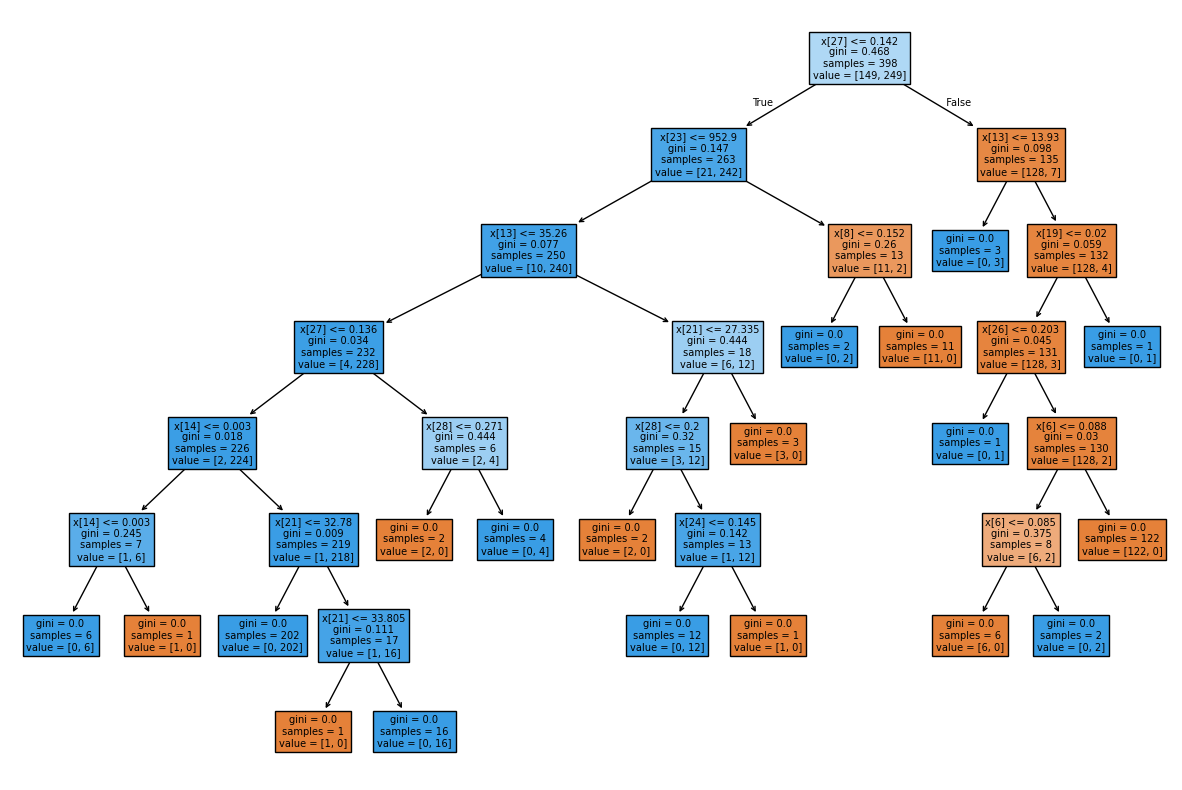

In [10]:
from sklearn import tree
plt.figure(figsize=(15,10))
tree.plot_tree(model,filled=True )

In [12]:
## Perform Pruning
path=model.cost_complexity_pruning_path(X_train,y_train)
path

{'ccp_alphas': array([0.        , 0.00249033, 0.00463858, 0.00487285, 0.00489632,
        0.00742172, 0.0080402 , 0.00838676, 0.00850406, 0.01386055,
        0.04035621, 0.33798172]),
 'impurities': array([0.        , 0.00996131, 0.01459989, 0.03409128, 0.04388392,
        0.05130564, 0.05934584, 0.0677326 , 0.07623666, 0.09009721,
        0.13045342, 0.46843514])}

In [14]:
# ccp_alphas is a list of pruning strengths (alpha values).
# Each value represents how much pruning should be applied to the decision tree.
ccp_alphas =path.ccp_alphas 

# Shows the impurity of the tree after pruning with each alpha.
impurities =path.impurities

In [18]:
# This code trains multiple pruned Decision Trees using
# different ccp_alpha values and stores them so you can choose the best-performing model.

clfs=[]
for ccp_alpha in ccp_alphas:
    model=DecisionTreeClassifier(random_state=0 ,ccp_alpha=ccp_alpha)
    model.fit(X_train,y_train)
    clfs.append(model)
print("Number of nodes in the last tree is: {} with ccp_alpha: {}".format(clfs[-1].tree_.node_count, ccp_alphas[-1]))

Number of nodes in the last tree is: 1 with ccp_alpha: 0.3379817186504386


## Accuracy vs alpha for training and testing sets
When ccp_alpha is set to zero and keeping the other default parameters of :class:DecisionTreeClassifier, the tree overfits, leading to a 100% training accuracy and 92% testing accuracy. As alpha increases, more of the tree is pruned, thus creating a decision tree that generalizes better. In this example, setting ccp_alpha=0.02 maximizes the testing accuracy.

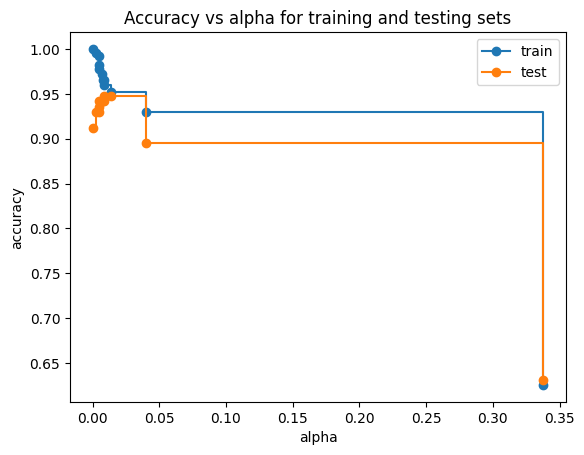

In [20]:
## plot the accuracy of train and test interm of ccp pruning

train_score=[clf.score(X_train,y_train) for clf in clfs]
test_score=[clf.score(X_test,y_test) for clf in clfs]

# fig → Whole figure (canvas).
# ax → Area where the graph is plotted.
fig, ax = plt.subplots()

ax.set_xlabel("alpha")
ax.set_ylabel("accuracy")
ax.set_title("Accuracy vs alpha for training and testing sets")
ax.plot(ccp_alphas, train_score, marker='o', label="train",
        drawstyle="steps-post")
ax.plot(ccp_alphas, test_score, marker='o', label="test",
        drawstyle="steps-post")
ax.legend()
plt.show()

In [22]:
# use ccp-alpha with 0.02 maxumum test accuracy according to plot
clf = DecisionTreeClassifier(random_state=0, ccp_alpha=0.02)
clf.fit(X_train,y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",0
,"ccp_alpha ccp_alpha: non-negative float, default=0.0Complexity parameter used for Minimal Cost-Complexity Pruning. Thesubtree with the largest cost complexity that is smaller than``ccp_alpha`` will be chosen. By default, no pruning is performed. See:ref:`minimal_cost_complexity_pruning` for details. See:ref:`sphx_glr_auto_examples_tree_plot_cost_complexity_pruning.py`for an example of such pruning... versionadded:: 0.22",0.02
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If Non

In [24]:
pred=clf.predict(X_test)
from sklearn.metrics import accuracy_score
accuracy_score(y_test, pred)
## ACCURACY INCREASE FORM 91% to 94%

0.9473684210526315

[Text(0.6, 0.8333333333333334, 'x[27] <= 0.142\ngini = 0.468\nsamples = 398\nvalue = [149, 249]'),
 Text(0.4, 0.5, 'x[23] <= 952.9\ngini = 0.147\nsamples = 263\nvalue = [21, 242]'),
 Text(0.5, 0.6666666666666667, 'True  '),
 Text(0.2, 0.16666666666666666, 'gini = 0.077\nsamples = 250\nvalue = [10, 240]'),
 Text(0.6, 0.16666666666666666, 'gini = 0.26\nsamples = 13\nvalue = [11, 2]'),
 Text(0.8, 0.5, 'gini = 0.098\nsamples = 135\nvalue = [128, 7]'),
 Text(0.7, 0.6666666666666667, '  False')]

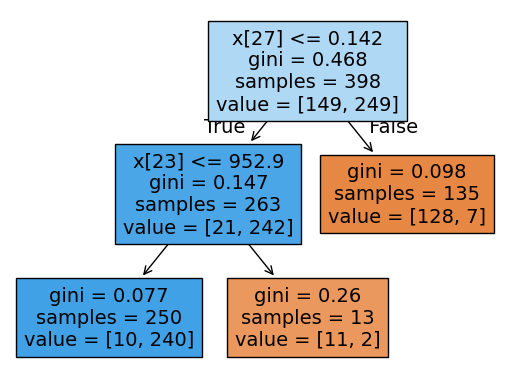

In [30]:
from sklearn import tree
# plt.figure(figsize=(15,10))
tree.plot_tree(clf,filled=True)